In [ ]:
!%pip install networkx matplotlib numpy

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

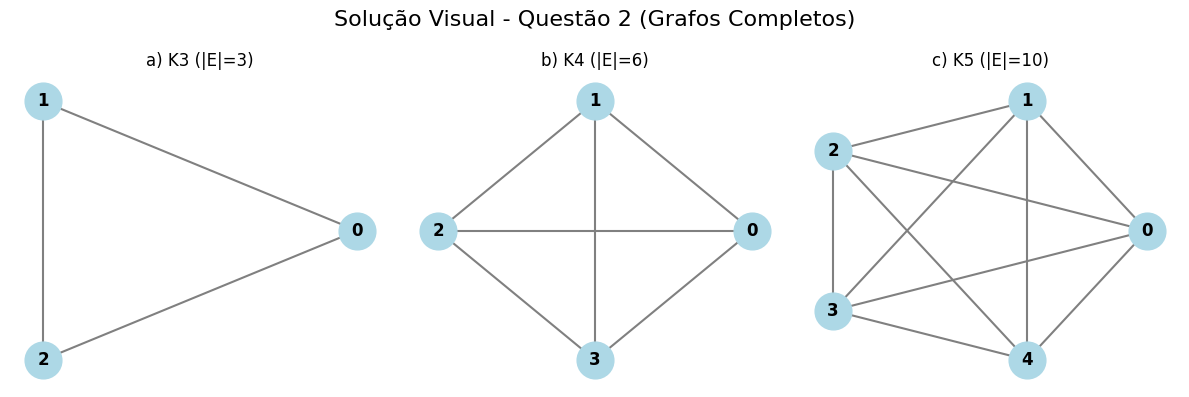

In [ ]:
# Configuração para Questão 2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titulos = ["a) K3 (|E|=3)", "b) K4 (|E|=6)", "c) K5 (|E|=10)"]
ns = [3, 4, 5]

for i, n in enumerate(ns):
    G = nx.complete_graph(n)
    pos = nx.circular_layout(G)
    nx.draw(G, pos, ax=axes[i], with_labels=True, node_color='#add8e6',
            edge_color='gray', node_size=700, font_weight='bold', width=1.5)
    axes[i].set_title(titulos[i])
    axes[i].axis('off') # Remove box border for cleaner look

plt.suptitle("Solução Visual - Questão 2 (Grafos Completos)", fontsize=16)
plt.tight_layout()
plt.show()

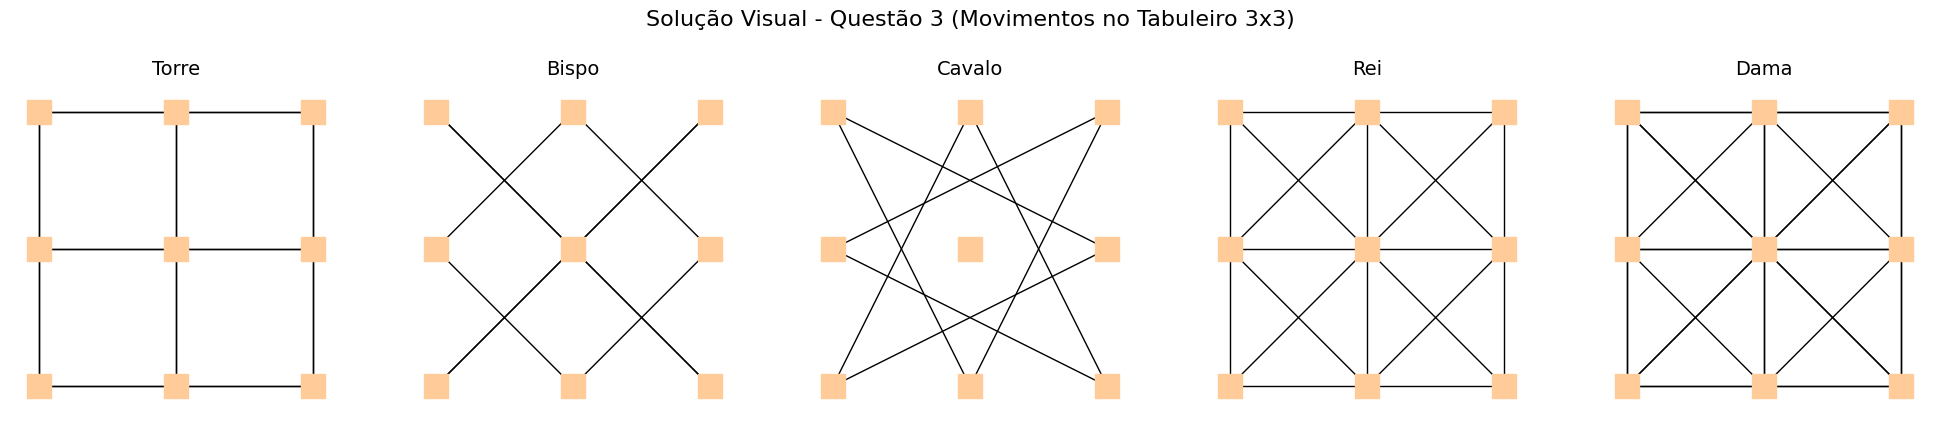

In [ ]:
def get_chess_graph(piece, n=3):
    G = nx.Graph()
    # Adiciona nós como coordenadas (row, col)
    nodes = [(r, c) for r in range(n) for c in range(n)]
    G.add_nodes_from(nodes)

    for r1, c1 in nodes:
        for r2, c2 in nodes:
            if (r1, c1) == (r2, c2):
                continue

            diff_r = abs(r1 - r2)
            diff_c = abs(c1 - c2)

            is_edge = False

            if piece == 'Torre':
                if (diff_r == 0) or (diff_c == 0): is_edge = True
            elif piece == 'Bispo':
                if diff_r == diff_c: is_edge = True
            elif piece == 'Cavalo':
                if (diff_r == 2 and diff_c == 1) or (diff_r == 1 and diff_c == 2): is_edge = True
            elif piece == 'Rei':
                if diff_r <= 1 and diff_c <= 1: is_edge = True
            elif piece == 'Dama':
                # Torre + Bispo
                if (diff_r == 0) or (diff_c == 0) or (diff_r == diff_c): is_edge = True

            if is_edge:
                G.add_edge((r1, c1), (r2, c2))
    return G

pieces = ['Torre', 'Bispo', 'Cavalo', 'Rei', 'Dama']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, piece in enumerate(pieces):
    G = get_chess_graph(piece)
    # Posicionar como matriz (y invertido para ficar como matriz visual)
    pos = {(r, c): (c, -r) for r, c in G.nodes()}

    nx.draw(G, pos, ax=axes[i], with_labels=False, node_color='#ffcc99',
            edge_color='black', node_size=300, node_shape='s')

    # Desenhar labels deslocados ou apenas os nós
    axes[i].set_title(f"{piece}", fontsize=14)
    axes[i].set_aspect('equal')
    axes[i].axis('off')

plt.suptitle("Solução Visual - Questão 3 (Movimentos no Tabuleiro 3x3)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

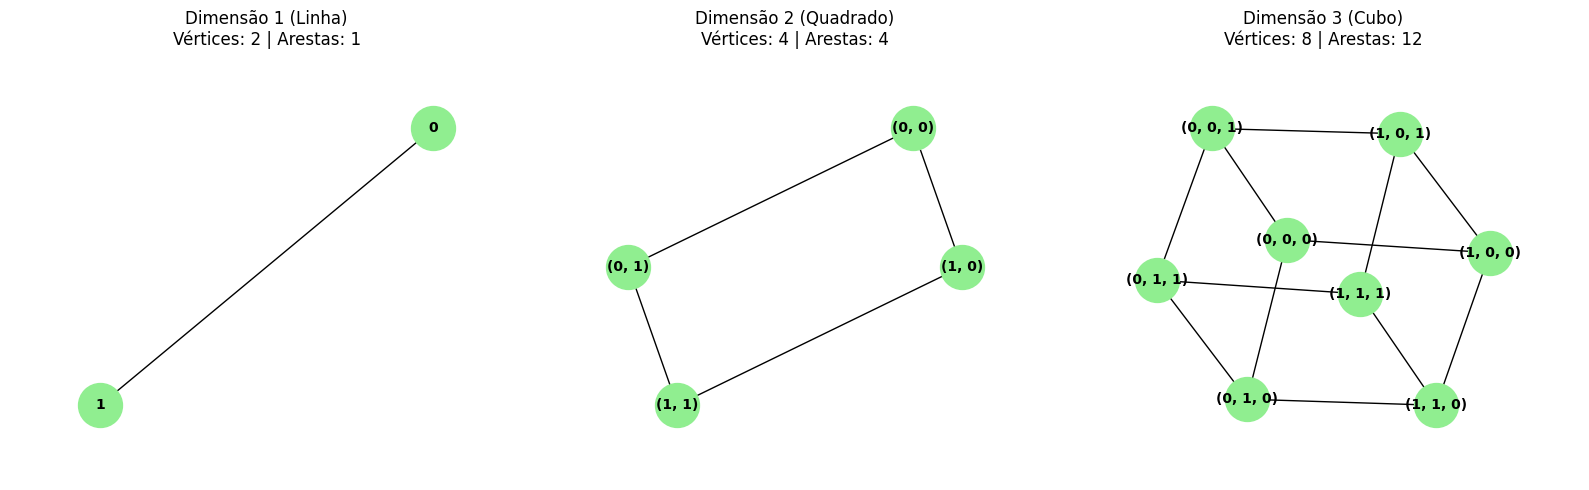

In [ ]:
# Configuração da figura
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
dimensoes = [1, 2, 3]
titulos = ["Dimensão 1 (Linha)", "Dimensão 2 (Quadrado)", "Dimensão 3 (Cubo)"]

for i, k in enumerate(dimensoes):
    # Gerar o hipercubo de dimensão k
    G = nx.hypercube_graph(k)

    # Layouts específicos para ficar bonito visualmente
    if k == 1:
        pos = nx.spring_layout(G)
    elif k == 2:
        pos = nx.spectral_layout(G) # Spectral costuma gerar o quadrado perfeito
    else:
        # Layout spring ajustado para simular 3D
        pos = nx.spring_layout(G, seed=42)

    # Desenhar
    nx.draw(G, pos, ax=axes[i], with_labels=True,
            node_color='#90EE90', edge_color='black',
            node_size=1000, font_weight='bold', font_size=10)

    axes[i].set_title(f"{titulos[i]}\nVértices: {2**k} | Arestas: {k * 2**(k-1)}", fontsize=12)
    axes[i].margins(0.2)

plt.tight_layout()
plt.show()

/tmp/ipython-input-567195259.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


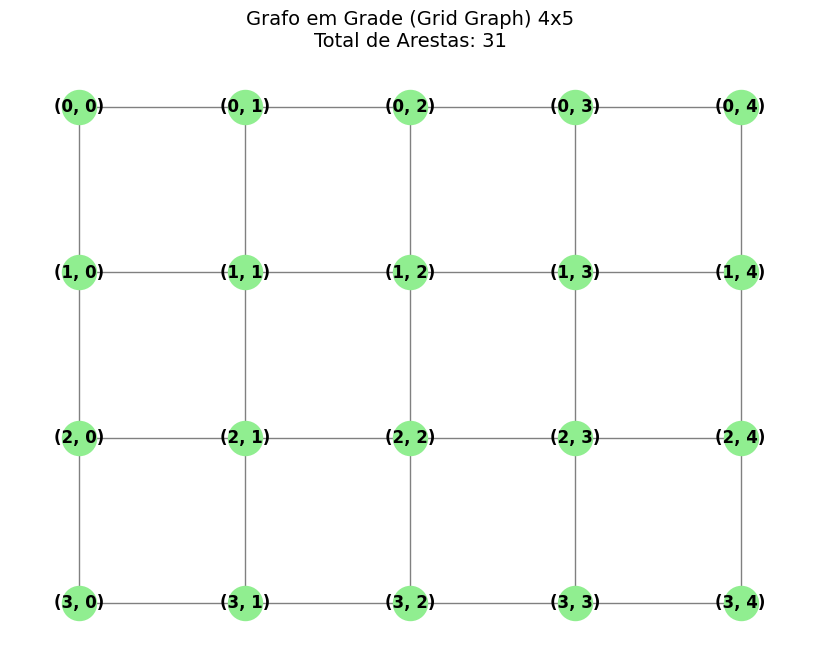

In [ ]:
# Configuração da grade
p, q = 4, 5  # Exemplo 4x5
G = nx.grid_2d_graph(p, q)

# Cálculo teórico para conferir
total_arestas = 2*p*q - p - q

plt.figure(figsize=(8, 6))

# Posicionar os nós como uma grade visual
pos = {(x, y): (y, -x) for x, y in G.nodes()}

nx.draw(G, pos,
        with_labels=True,
        node_color='lightgreen',
        edge_color='gray',
        node_size=600,
        font_weight='bold')

plt.title(f"Grafo em Grade (Grid Graph) {p}x{q}\nTotal de Arestas: {total_arestas}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

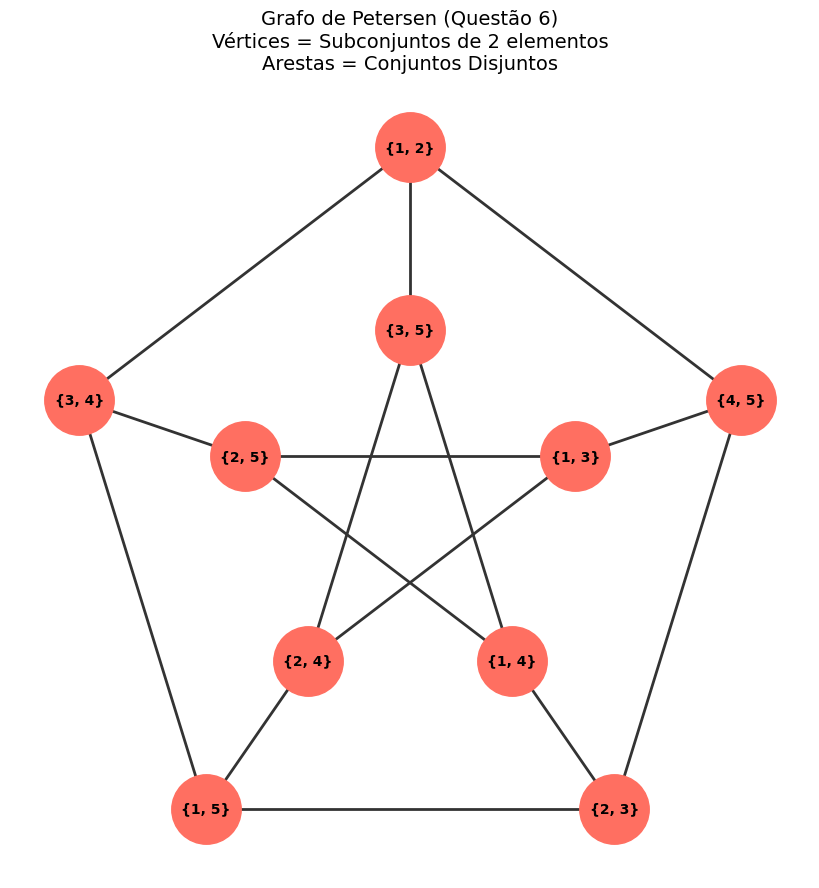

In [ ]:
# Criar o grafo
G = nx.Graph()

# Definir os vértices (todas as combinações de 2 elementos de 1 a 5)
elementos = [1, 2, 3, 4, 5]
vertices = []
from itertools import combinations
for p in combinations(elementos, 2):
    vertices.append(set(p))

# Adicionar arestas se a interseção for vazia
for v1 in vertices:
    for v2 in vertices:
        if v1 != v2:
            if v1.isdisjoint(v2):
                # Converter para string para usar como label no grafo
                s1 = str(sorted(list(v1))).replace('[','{').replace(']','}')
                s2 = str(sorted(list(v2))).replace('[','{').replace(']','}')
                G.add_edge(s1, s2)

# Configuração manual de Posição para o layout clássico do Petersen
# O Ciclo externo será: {1,2} -> {3,4} -> {1,5} -> {2,3} -> {4,5}
# Os nós internos conectam-se radialmente a estes.
pos = {}
r_ext = 2
r_int = 1
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, 6)[:-1] # Começa em 90 graus

# Ordem específica para o pentágono externo ficar correto
outer_nodes = ["{1, 2}", "{3, 4}", "{1, 5}", "{2, 3}", "{4, 5}"]
# Seus pares internos correspondentes (disjuntos dos externos)
inner_nodes = ["{3, 5}", "{2, 5}", "{2, 4}", "{1, 4}", "{1, 3}"]

for i, angle in enumerate(angles):
    # Nó externo
    x_ext = r_ext * np.cos(angle)
    y_ext = r_ext * np.sin(angle)
    pos[outer_nodes[i]] = (x_ext, y_ext)

    # Nó interno correspondente (na mesma direção radial)
    x_int = r_int * np.cos(angle)
    y_int = r_int * np.sin(angle)
    pos[inner_nodes[i]] = (x_int, y_int)

# Desenhar
plt.figure(figsize=(8, 8))
nx.draw(G, pos,
        with_labels=True,
        node_color='#FF6F61',
        edge_color='#333333',
        node_size=2500,
        font_size=10,
        font_weight='bold',
        width=2)

plt.title("Grafo de Petersen (Questão 6)\nVértices = Subconjuntos de 2 elementos\nArestas = Conjuntos Disjuntos", fontsize=14)
plt.axis('off') # Remove eixos
plt.show()

/tmp/ipython-input-963494040.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


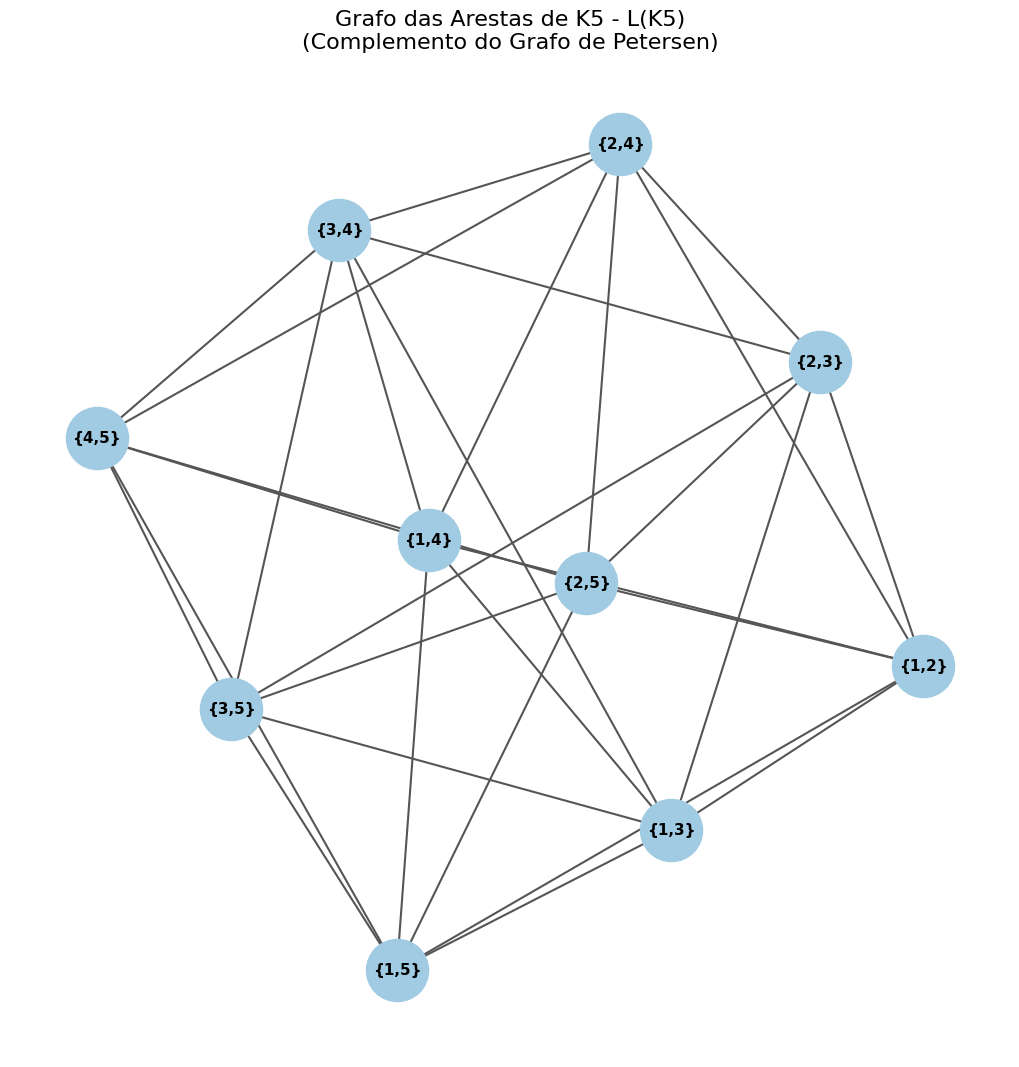

In [ ]:
# 1. Criar o grafo original K5
K5 = nx.complete_graph(5)

# 2. Gerar o grafo das arestas (Line Graph) de K5
L_K5 = nx.line_graph(K5)

# 3. Renomear os vértices para ficar mais claro (de tuplas (0,1) para strings "{1,2}")
mapping = {node: f"{{{node[0]+1},{node[1]+1}}}" for node in L_K5.nodes()}
L_K5 = nx.relabel_nodes(L_K5, mapping)

# 4. Configurar o desenho
plt.figure(figsize=(10, 10))

# Usar um layout de força (spring/kamada_kawai) para obter uma forma simétrica e agradável
pos = nx.kamada_kawai_layout(L_K5)

# Desenhar o grafo
nx.draw(L_K5, pos,
        with_labels=True,
        node_color='#A0CBE2', # Um azul claro
        edge_color='#555555', # Cinza escuro para as arestas
        node_size=2000,       # Vértices grandes para ler os rótulos
        font_size=11,         # Tamanho da fonte
        font_weight='bold',
        width=1.5)            # Espessura das arestas

plt.title("Grafo das Arestas de K5 - L(K5)\n(Complemento do Grafo de Petersen)", fontsize=16)
plt.axis('off') # Remover eixos
plt.tight_layout()
plt.show()

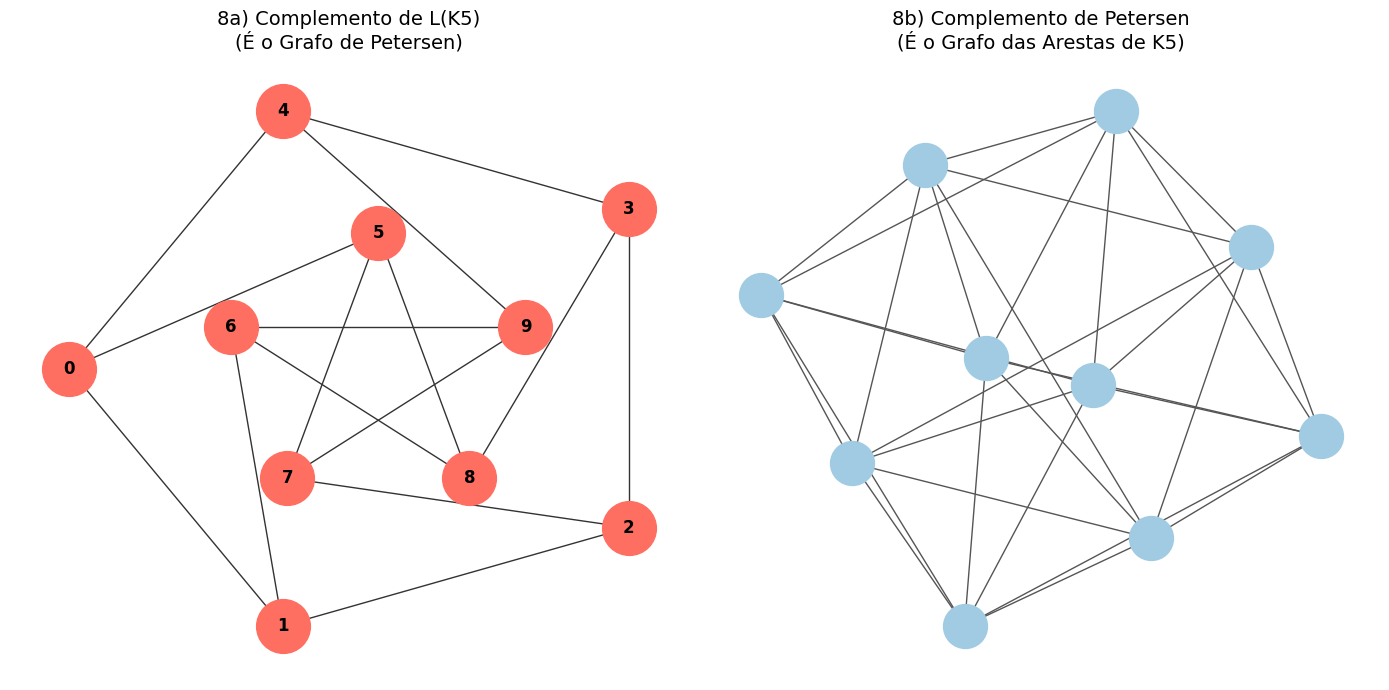

In [ ]:
# Configuração da figura
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- GRÁFICO 1: Resposta de 8a (Grafo de Petersen) ---
# O complemento de L(K5) é isomorfo ao Petersen
G_petersen = nx.petersen_graph()
# Layout Shell (conchas) para fazer o pentágono+estrela
pos_petersen = nx.shell_layout(G_petersen, nlist=[range(5, 10), range(5)])

nx.draw(G_petersen, pos_petersen, ax=axes[0],
        with_labels=True,
        node_color='#FF6F61',
        edge_color='#333333',
        node_size=1500, font_weight='bold')
axes[0].set_title("8a) Complemento de L(K5)\n(É o Grafo de Petersen)", fontsize=14)


# --- GRÁFICO 2: Resposta de 8b (L(K5)) ---
# O complemento do Petersen é isomorfo ao L(K5)
K5 = nx.complete_graph(5)
L_K5 = nx.line_graph(K5)

# Layout circular ou Kamada-Kawai para mostrar a simetria
pos_lk5 = nx.kamada_kawai_layout(L_K5)

nx.draw(L_K5, pos_lk5, ax=axes[1],
        node_color='#A0CBE2',
        edge_color='#555555',
        node_size=1000) # Sem labels numéricos aqui para não poluir, pois a estrutura importa mais
axes[1].set_title("8b) Complemento de Petersen\n(É o Grafo das Arestas de K5)", fontsize=14)

plt.tight_layout()
plt.show()

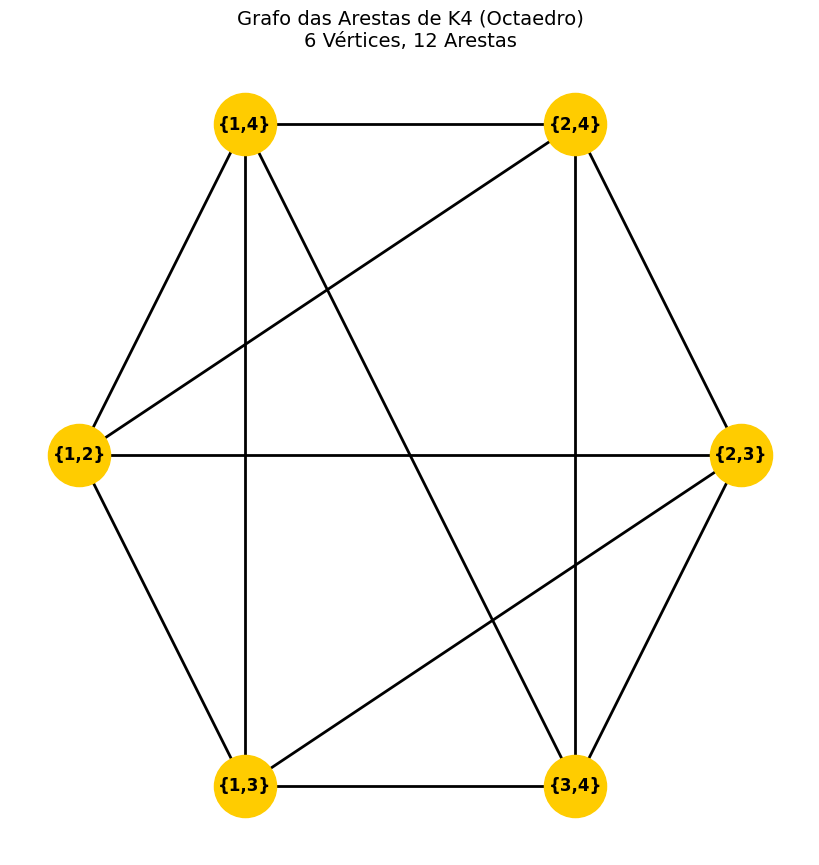

In [ ]:
# 1. Criar o grafo K4
K4 = nx.complete_graph(4)

# 2. Gerar o grafo das arestas (Line Graph)
L_K4 = nx.line_graph(K4)

# 3. Renomear os nós para mostrar os pares
mapping = {node: f"{{{node[0]+1},{node[1]+1}}}" for node in L_K4.nodes()}
L_K4 = nx.relabel_nodes(L_K4, mapping)

# 4. Desenhar
plt.figure(figsize=(8, 8))

# O layout circular funciona bem para mostrar a simetria do Octaedro
pos = nx.circular_layout(L_K4)

nx.draw(L_K4, pos,
        with_labels=True,
        node_color='#ffcc00', # Amarelo/Laranja
        edge_color='black',
        node_size=2000,
        font_weight='bold',
        width=2)

plt.title("Grafo das Arestas de K4 (Octaedro)\n6 Vértices, 12 Arestas", fontsize=14)
plt.axis('off')
plt.show()

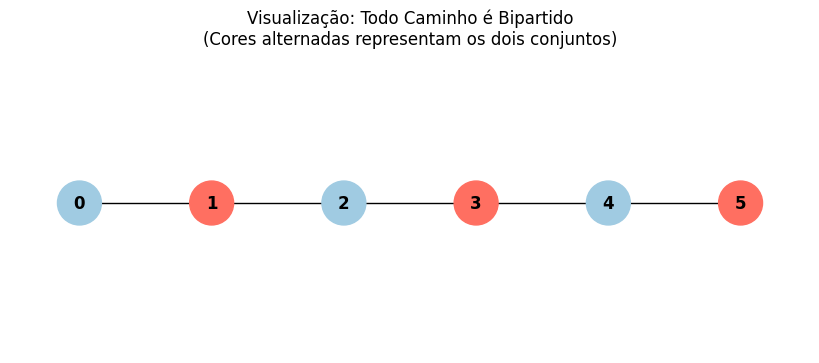

In [ ]:
# Criar um caminho simples com 6 nós
G = nx.path_graph(6)

# Definir cores para os conjuntos bipartidos
color_map = []
for node in G:
    if node % 2 == 0:
        color_map.append('#A0CBE2') # Azul (Conjunto A - Pares na indexação 0 do python)
    else:
        color_map.append('#FF6F61') # Vermelho (Conjunto B - Ímpares)

plt.figure(figsize=(8, 3))
pos = nx.spring_layout(G)
# Forçar layout linear para visualizar melhor o caminho
pos = {i: (i, 0) for i in G.nodes()}

nx.draw(G, pos,
        node_color=color_map,
        with_labels=True,
        edge_color='black',
        node_size=1000,
        font_weight='bold')

plt.title("Visualização: Todo Caminho é Bipartido\n(Cores alternadas representam os dois conjuntos)", fontsize=12)
plt.axis('off')
plt.show()

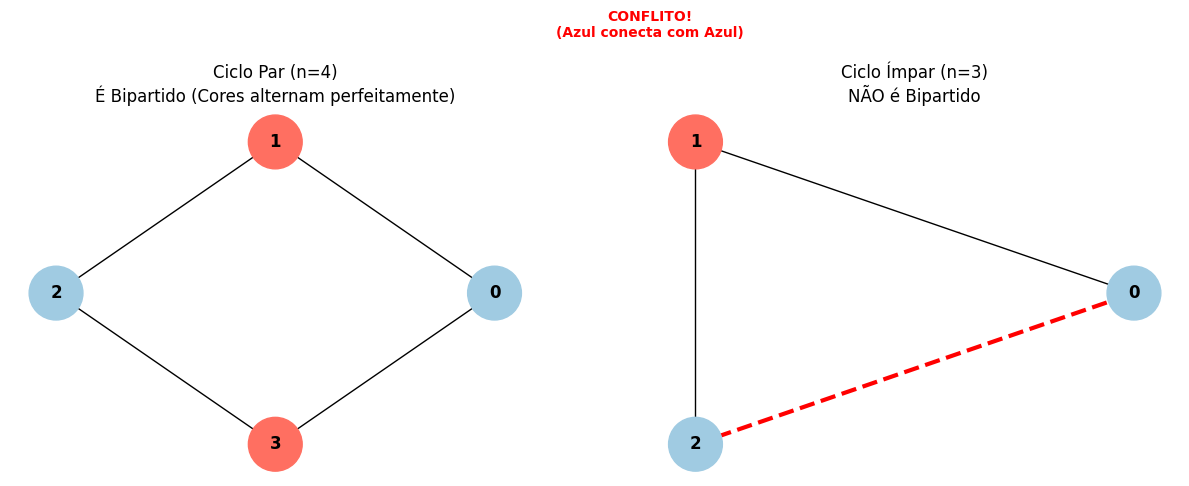

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- GRÁFICO 1: Ciclo Par (C4 - Quadrado) ---
G_even = nx.cycle_graph(4)
# Cores alternadas manualmente
colors_even = ['#A0CBE2', '#FF6F61', '#A0CBE2', '#FF6F61'] # Azul, Vermelho, Azul, Vermelho

pos_even = nx.circular_layout(G_even)
nx.draw(G_even, pos_even, ax=axes[0],
        node_color=colors_even,
        with_labels=True,
        edge_color='black',
        node_size=1500, font_weight='bold')
axes[0].set_title("Ciclo Par (n=4)\nÉ Bipartido (Cores alternam perfeitamente)", fontsize=12)

# --- GRÁFICO 2: Ciclo Ímpar (C3 - Triângulo) ---
G_odd = nx.cycle_graph(3)
# Tentativa de alternar
colors_odd = ['#A0CBE2', '#FF6F61', '#A0CBE2'] # Azul, Vermelho... O último (2) é Azul

pos_odd = nx.circular_layout(G_odd)
# Desenhar nós
nx.draw_networkx_nodes(G_odd, pos_odd, ax=axes[1], node_color=colors_odd, node_size=1500)
nx.draw_networkx_labels(G_odd, pos_odd, ax=axes[1], font_weight='bold')

# Desenhar arestas normais
nx.draw_networkx_edges(G_odd, pos_odd, ax=axes[1], edgelist=[(0,1), (1,2)])

# Destacar a aresta de conflito
nx.draw_networkx_edges(G_odd, pos_odd, ax=axes[1], edgelist=[(2,0)],
                       edge_color='red', width=3, style='dashed')

# Anotação do conflito
axes[1].annotate("CONFLITO!\n(Azul conecta com Azul)",
                 xy=pos_odd[0], xytext=(0, 1.2),
                 textcoords='axes fraction', ha='center', color='red', weight='bold')

axes[1].set_title("Ciclo Ímpar (n=3)\nNÃO é Bipartido", fontsize=12)
axes[1].axis('off')
axes[0].axis('off')

plt.tight_layout()
plt.show()

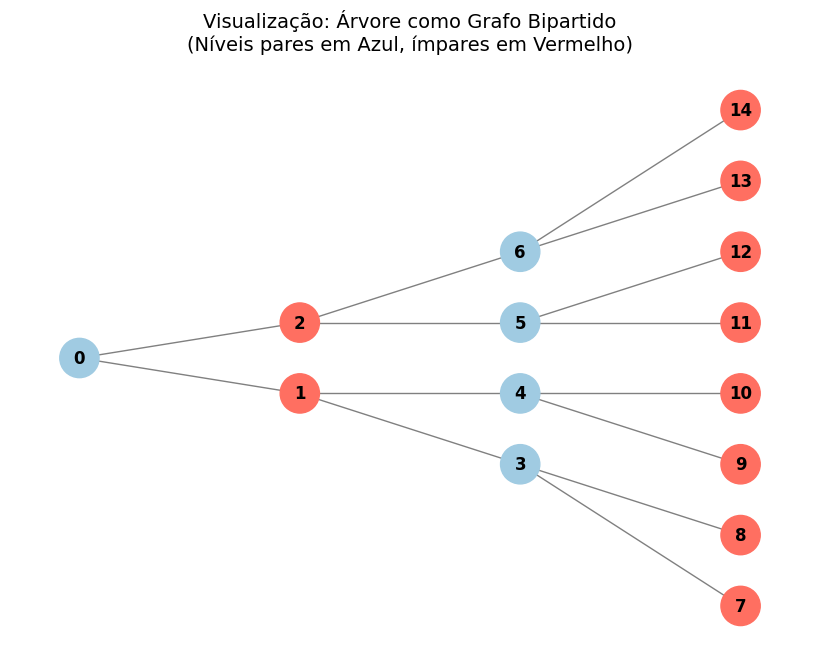

In [ ]:
# Criar uma árvore aleatória
G = nx.balanced_tree(r=2, h=3) # Árvore binária de altura 3

# Definir cores baseadas na paridade do nível (distância da raiz '0')
colors = []
for node in G.nodes():
    # Calcular distância da raiz (nó 0)
    dist = nx.shortest_path_length(G, source=0, target=node)
    if dist % 2 == 0:
        colors.append('#A0CBE2') # Azul (Nível Par)
    else:
        colors.append('#FF6F61') # Vermelho (Nível Ímpar)

plt.figure(figsize=(8, 6))
# Layout hierárquico (árvore)
pos = nx.bfs_layout(G, start=0)

nx.draw(G, pos,
        node_color=colors,
        with_labels=True,
        edge_color='gray',
        node_size=800,
        font_weight='bold')

plt.title("Visualização: Árvore como Grafo Bipartido\n(Níveis pares em Azul, ímpares em Vermelho)", fontsize=14)
plt.axis('off')
plt.show()

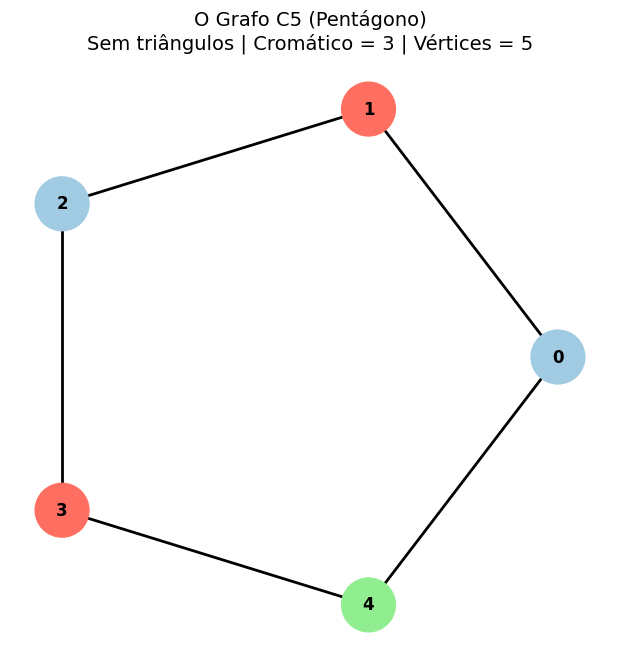

In [ ]:
# Criar o grafo C5 (Ciclo de 5 vértices)
G = nx.cycle_graph(5)

# Definir uma coloração válida com 3 cores (greddy coloring ou manual)
# Vértices: 0-1-2-3-4-0
# Cores manuais para provar que precisa de 3:
# 0: Azul, 1: Vermelho, 2: Azul, 3: Vermelho -> 4 conecta em 0(A) e 3(V), precisa ser Verde.
node_colors = ['#A0CBE2', '#FF6F61', '#A0CBE2', '#FF6F61', '#90EE90']
# Azul, Vermelho, Azul, Vermelho, Verde

plt.figure(figsize=(6, 6))
pos = nx.circular_layout(G)

nx.draw(G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color='black',
        node_size=1500,
        font_weight='bold',
        font_size=12,
        width=2)

plt.title("O Grafo C5 (Pentágono)\nSem triângulos | Cromático = 3 | Vértices = 5", fontsize=14)
plt.axis('off')
plt.show()

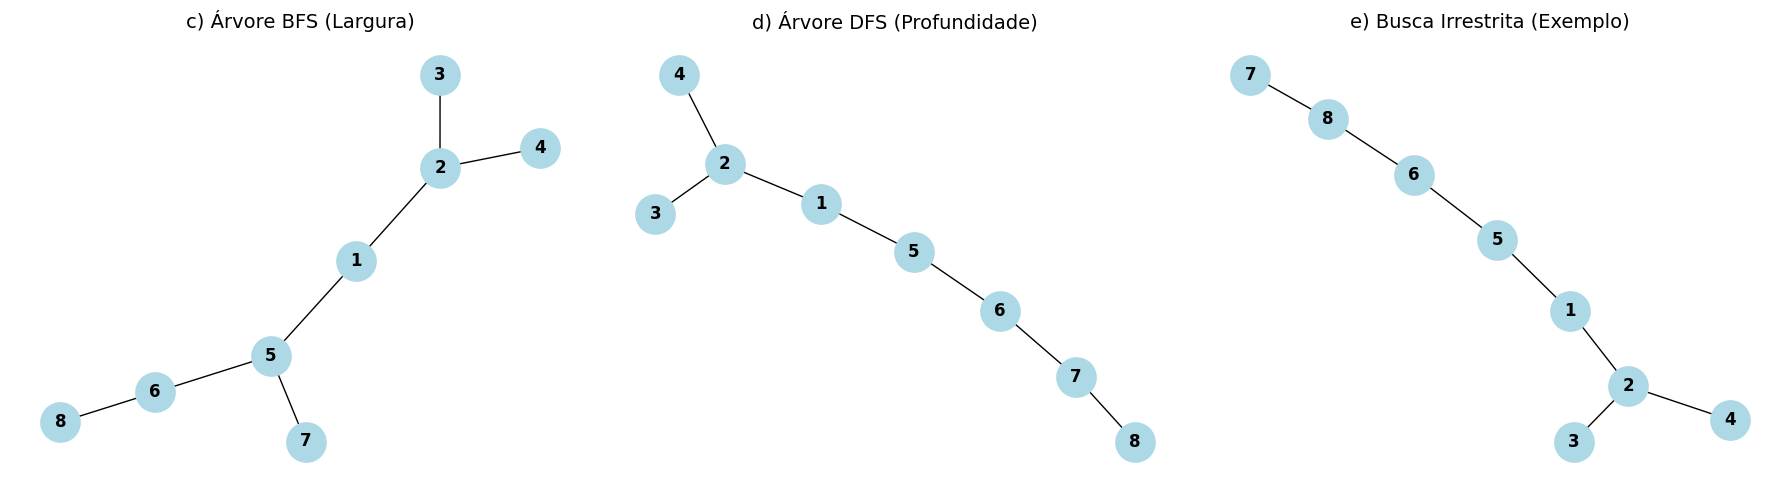

In [ ]:
# Definir as arestas das árvores calculadas
bfs_edges = [(1,2), (1,5), (2,3), (2,4), (5,6), (5,7), (6,8)]
dfs_edges = [(1,2), (2,3), (2,4), (1,5), (5,6), (6,7), (7,8)]
# Exemplo Irrestrito (Aleatório)
irrestrita_edges = [(1,5), (5,6), (6,8), (8,7), (1,2), (2,4), (2,3)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def draw_tree(ax, edges, title, root_pos):
    G = nx.Graph()
    G.add_edges_from(edges)
    # Layout hierárquico manual simples para visualização
    pos = nx.spring_layout(G, seed=42) # Fallback

    # Tentativa de layout hierárquico (dot)
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot', root='1')
    except:
        pass

    nx.draw(G, pos, ax=ax, with_labels=True,
            node_color='lightblue', edge_color='black',
            node_size=800, font_weight='bold')
    ax.set_title(title, fontsize=14)

draw_tree(axes[0], bfs_edges, "c) Árvore BFS (Largura)", 1)
draw_tree(axes[1], dfs_edges, "d) Árvore DFS (Profundidade)", 1)
draw_tree(axes[2], irrestrita_edges, "e) Busca Irrestrita (Exemplo)", 1)

plt.tight_layout()
plt.show()


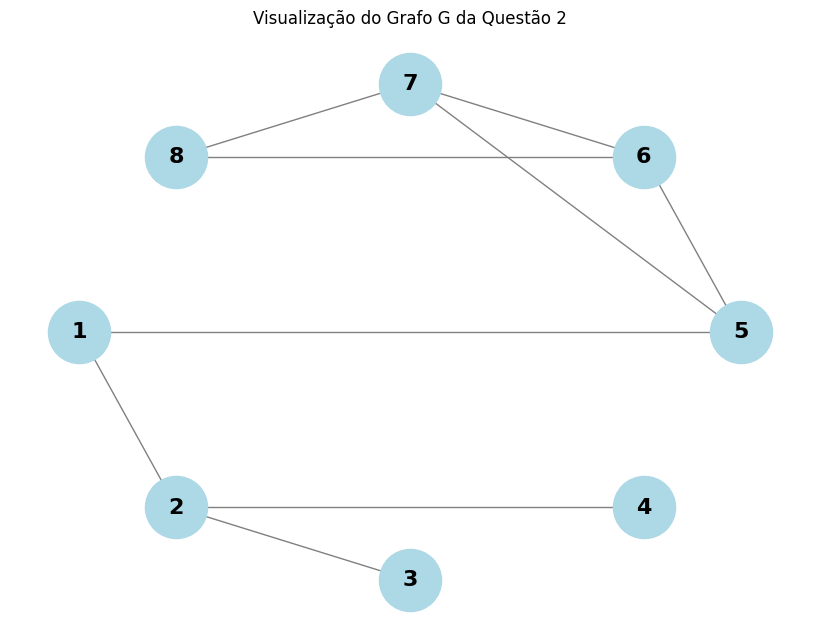

Vértices: [1, 2, 3, 4, 5, 6, 7, 8]
Arestas: [(1, 2), (1, 5), (2, 3), (2, 4), (5, 6), (5, 7), (6, 7), (6, 8), (7, 8)]


In [ ]:
# 1. Criação do Grafo (Não direcionado)
G = nx.Graph()

# 2. Adicionando os Vértices (1 a 8)
G.add_nodes_from([1, 2, 3, 4, 5, 6, 7, 8])

# 3. Adicionando as Arestas conforme a questão
# Lista: {12, 23, 24, 15, 56, 57, 67, 68, 78}
arestas = [
    (1, 2), (1, 5),
    (2, 3), (2, 4),
    (5, 6), (5, 7),
    (6, 7), (6, 8),
    (7, 8)
]
G.add_edges_from(arestas)

# --- Visualização (Opcional) ---
plt.figure(figsize=(8, 6))

# Layout fixo para ficar organizado (hierárquico ajuda a ver os níveis)
# Usando shell layout para destacar o ciclo e as ramificações
pos = nx.shell_layout(G)

nx.draw(G, pos,
        with_labels=True,
        node_color='lightblue',
        edge_color='gray',
        node_size=2000,
        font_size=16,
        font_weight='bold')

plt.title("Visualização do Grafo G da Questão 2")
plt.show()

# Verificar informações básicas
print(f"Vértices: {G.nodes()}")
print(f"Arestas: {G.edges()}")

In [ ]:
# Representação por Lista de Adjacência (Dicionário de Listas)
# Chave: Vértice
# Valor: Lista de Vizinhos (ordenados para seguir a regra do exercício)

grafo_g = {
    1: [2, 5],
    2: [1, 3, 4],
    3: [2],
    4: [2],
    5: [1, 6, 7],
    6: [5, 7, 8],
    7: [5, 6, 8],
    8: [6, 7]
}

# Exemplo de como acessar os vizinhos
print("Vizinhos do vértice 5:", grafo_g[5])

# Função simples para verificar conexões
def existe_aresta(u, v):
    return v in grafo_g.get(u, [])

print(f"Existe aresta entre 1 e 5? {existe_aresta(1, 5)}") # True
print(f"Existe aresta entre 1 e 3? {existe_aresta(1, 3)}") # False

Vizinhos do vértice 5: [1, 6, 7]
Existe aresta entre 1 e 5? True
Existe aresta entre 1 e 3? False


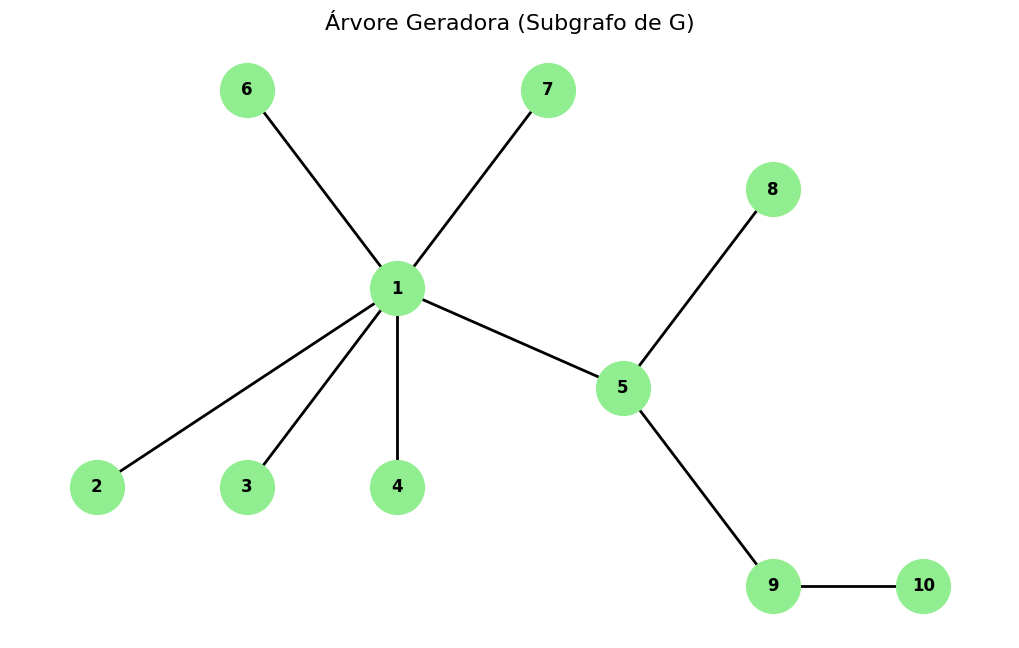

In [ ]:
# 1. Criar o grafo vazio
T = nx.Graph()

# 2. Adicionar os vértices (1 a 10)
T.add_nodes_from(range(1, 11))

# 3. Adicionar as arestas da Árvore (Subgrafo de G)
# Estrutura escolhida:
# - O vértice 1 é o centro e conecta com quase todos ao redor.
# - O vértice 5 estende para a direita (8 e 9).
# - O vértice 9 conecta o último ponto (10).
arestas_arvore = [
    (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), # Conexões diretas do 1
    (5, 8), (5, 9),                                 # Extensões a partir do 5
    (9, 10)                                         # Extensão final para o 10
]

T.add_edges_from(arestas_arvore)

# --- Configuração Visual ---
plt.figure(figsize=(10, 6))

# Definindo um layout hierárquico manual para parecer uma árvore
# Isso ajuda a visualizar quem é "pai" de quem
posicao = {
    1: (0, 0),      # Raiz no centro
    2: (-2, -1), 3: (-1, -1), 4: (0, -1), 5: (1.5, -0.5), 6: (-1, 1), 7: (1, 1),
    8: (2.5, 0.5), 9: (2.5, -1.5),
    10: (3.5, -1.5)
}

# Desenhar o grafo
nx.draw(T, posicao,
        with_labels=True,
        node_color='#90EE90',  # Verde claro
        edge_color='black',
        node_size=1500,
        font_size=12,
        font_weight='bold',
        width=2)

plt.title("Árvore Geradora (Subgrafo de G)", fontsize=16)
plt.axis('off') # Remove as bordas dos eixos
plt.show()